In [1]:
# ════════════════════════════════════════════════════════════
# 03. Q-G-CTGAN (Proposed Method) — FINAL VERSION
# Q-G-CTGAN: Quality-Aware Cluster-Conditioned Oversampling
#             via Intra-Cluster Synthetic Sample Filtering
#
# Pipeline:
#   1. GMM clustering on minority class (BIC-optimal k*)
#   2. Per-cluster CTGAN training (once per dataset, reused across
#      all alpha/MMD configurations)
#   3. Target-aware candidate generation: multiplier is computed per
#      dataset to approach the Delta = n_maj - n_min target, bounded
#      to [5.0x, 50.0x] (resolves Reviewer #4, R4-1)
#   4. Two-stage quality filtering:
#        Stage 1 — Q(x̃) = (1/3)*S_density + (1/3)*S_sep + (1/3)*S_lof,
#                  alpha_c is a REJECTION QUANTILE (resolves R4-3)
#        Stage 2 — MMD contribution-based final selection (can be
#                  disabled for ablation, Reviewer #1 R1-8)
#   5. Adaptive threshold alpha_c (GMM mean log-likelihood based,
#      resolves R4-2)
#   6. Fixed alpha ablation: alpha in {0.1, 0.2, 0.3}
#   7. MMD stage on/off ablation (R1-8)
#   8. Extended metrics: AUC, PR-AUC, F1, Precision, Recall, G-mean,
#      Balanced Accuracy (R1-9)
#   9. Stage-by-stage runtime tracking (R1-6)
#
# Reads  : ./datasets/*.csv  (16 datasets: 11 original + 5 added in
#          the major revision)
# Writes : ./results/03_*.csv / *.png / *.pdf
# ════════════════════════════════════════════════════════════


# ════════════════════════════════════════════════════════════
## 0. Setup
# ════════════════════════════════════════════════════════════

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")

DATASET_DIR  = "./datasets"
RESULTS_DIR  = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# All 16 datasets: original 11 + 5 added during major revision (R1-3)
DATASET_NAMES = [
    # Original 11 (manuscript)
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
    # Added in major revision
    "satellite", "churn", "secom", "thyroid_sick", "unsw_nb15",
]

CLASSIFIERS = ["RF", "LGBM", "MLP"]

CANDIDATE_MULTIPLIER = 5.0    # manuscript's sensitivity-analysis-derived base (Section 3.4)
MAX_MULTIPLIER       = 50.0   # hard cap to bound runtime on extreme-IR datasets (R4-1 fix)
ALPHA_FIXED          = [0.1, 0.2, 0.3]
ALPHA_MIN            = 0.1
ALPHA_MAX            = 0.3
TARGET_RATIO         = 0.50

# Global figure quality settings (journal-ready)
mpl.rcParams.update({
    "figure.dpi"     : 300,
    "savefig.dpi"    : 300,
    "font.size"      : 9,
    "axes.titlesize" : 11,
    "axes.labelsize" : 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family"    : "sans-serif",
    "pdf.fonttype"   : 42,
    "ps.fonttype"    : 42,
})

def save_fig(fig, path_no_ext):
    """Save figure as PNG (300 dpi) and PDF (vector) simultaneously."""
    fig.savefig(path_no_ext + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf",           bbox_inches="tight")
    print(f"Figure saved -> {path_no_ext}.png / .pdf")

print(f"Datasets           : {len(DATASET_NAMES)}")
print(f"Classifiers        : {CLASSIFIERS}")
print(f"Candidate mult.    : base={CANDIDATE_MULTIPLIER}x, cap={MAX_MULTIPLIER}x")
print(f"Fixed alpha values : {ALPHA_FIXED}")
print(f"Adaptive alpha rng : [{ALPHA_MIN}, {ALPHA_MAX}]")
print(f"Target ratio       : {TARGET_RATIO}")


# ════════════════════════════════════════════════════════════
## 1. Classifiers & Evaluation  (extended metrics, R1-9)
# ════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, balanced_accuracy_score, confusion_matrix,
)
from lightgbm import LGBMClassifier


def get_classifier(name, random_state=RANDOM_STATE):
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=3,
            class_weight="balanced", random_state=random_state, n_jobs=-1,
        )
    elif name == "LGBM":
        return LGBMClassifier(
            n_estimators=100, learning_rate=0.05, num_leaves=31,
            class_weight="balanced", random_state=random_state,
            n_jobs=-1, verbose=-1,
        )
    elif name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=0.001,
            max_iter=300, random_state=random_state,
        )


def g_mean_score(y_true, y_pred):
    """Geometric mean of sensitivity (minority recall) and specificity
    (majority recall). Penalises classifiers that only perform well on
    the majority class."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return float(np.sqrt(sensitivity * specificity))


def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        "AUC"         : round(roc_auc_score(y_test, y_prob), 4),
        "PR_AUC"      : round(average_precision_score(y_test, y_prob), 4),
        "F1"          : round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Precision"   : round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall"      : round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "G_mean"      : round(g_mean_score(y_test, y_pred), 4),
        "Balanced_Acc": round(balanced_accuracy_score(y_test, y_pred), 4),
    }

print("Classifiers & Evaluation ready (AUC, PR-AUC, F1, Precision, Recall, G-mean, Balanced Accuracy).")


# ════════════════════════════════════════════════════════════
## 2. GMM Clustering
# ════════════════════════════════════════════════════════════

from sklearn.mixture import GaussianMixture


def fit_gmm(X_min, k, random_state=RANDOM_STATE):
    gmm = GaussianMixture(
        n_components=k, covariance_type="full",
        random_state=random_state, max_iter=200,
    )
    gmm.fit(X_min)
    return gmm


def select_optimal_k(X_min, k_range=range(2, 11), random_state=RANDOM_STATE):
    bic_scores = {}
    for k in k_range:
        if len(X_min) < k * 2:
            break
        try:
            gmm = fit_gmm(X_min, k, random_state)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue
    if not bic_scores:
        return 2, {}, fit_gmm(X_min, 2, random_state)
    best_k   = min(bic_scores, key=bic_scores.get)
    best_gmm = fit_gmm(X_min, best_k, random_state)
    return best_k, bic_scores, best_gmm

print("GMM clustering ready.")


# ════════════════════════════════════════════════════════════
## 3. Quality Score Functions  (Stage 1 core)
# ════════════════════════════════════════════════════════════

from scipy.spatial.distance import cdist
from sklearn.neighbors import LocalOutlierFactor


def s_density(X_syn, mu_c, sigma_c):
    """S_density = exp(-D_M(x̃, mu_c, Sigma_c)) — intra-cluster density score."""
    try:
        sigma_inv = np.linalg.pinv(sigma_c)
        diff      = X_syn - mu_c
        maha      = np.sqrt(np.einsum("ij,jk,ik->i", diff, sigma_inv, diff))
        return np.exp(-maha)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def s_sep(X_syn, mu_minority_all, mu_majority_clusters, eps=1e-8):
    """S_sep = d_maj / (d_maj + d_min + eps) — class separability score."""
    d_maj = cdist(X_syn, mu_majority_clusters).min(axis=1)
    d_min = cdist(X_syn, mu_minority_all).min(axis=1)
    return d_maj / (d_maj + d_min + eps)


def s_lof(X_syn, X_cluster_real, n_neighbors=5):
    """S_lof = 1 / LOF(x̃) — local outlier score (computed within cluster only)."""
    X_combined = np.vstack([X_cluster_real, X_syn])
    n_nb = min(n_neighbors, len(X_cluster_real) - 1)
    if n_nb < 1:
        return np.ones(len(X_syn)) * 0.5
    try:
        lof      = LocalOutlierFactor(n_neighbors=n_nb, novelty=False)
        lof.fit_predict(X_combined)
        lof_vals = -lof.negative_outlier_factor_[len(X_cluster_real):]
        return 1.0 / np.maximum(lof_vals, 1e-8)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def quality_score(X_syn, mu_c, sigma_c, mu_minority_all,
                  mu_majority_clusters, X_cluster_real,
                  w=(1/3, 1/3, 1/3)):
    """Q(x̃) = w1*S_density + w2*S_sep + w3*S_lof  (all normalised to [0,1])."""
    sd = s_density(X_syn, mu_c, sigma_c)
    ss = s_sep(X_syn, mu_minority_all, mu_majority_clusters)
    sl = s_lof(X_syn, X_cluster_real)

    def norm(v):
        lo, hi = v.min(), v.max()
        return (v - lo) / (hi - lo + 1e-8)

    return w[0]*norm(sd) + w[1]*norm(ss) + w[2]*norm(sl)

print("Quality score functions ready.")


# ════════════════════════════════════════════════════════════
## 4. Adaptive alpha  (GMM log-likelihood based)
# ════════════════════════════════════════════════════════════
# NOTE (Reviewer #4, R4-2): ell_c is the MEAN per-sample log-likelihood
# of cluster c (gmm.score_samples(X_c).mean()), not the summed
# log-likelihood ln p(C_c) as literally written in the manuscript. The
# mean avoids confounding cluster stability with cluster size: a summed
# log-likelihood grows more negative simply as a function of sample
# count, which would bias alpha_c toward large clusters regardless of
# their actual geometric stability.

def compute_adaptive_alpha(gmm, X_min, labels, best_k,
                           alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX):
    """
    alpha_c = alpha_max - (alpha_max - alpha_min) * ell_tilde_c
    High log-likelihood (stable cluster)   -> small alpha_c -> less filtering
        (a small quantile of candidates is rejected, R4-3)
    Low  log-likelihood (unstable cluster) -> large alpha_c -> more filtering
        (a large quantile of candidates is rejected, R4-3)
    """
    log_liks = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        ll  = gmm.score_samples(X_c).mean() if len(X_c) >= 2 else -np.inf
        log_liks.append(ll)

    ll = np.array(log_liks, dtype=float)
    valid = ll[np.isfinite(ll)]
    if len(valid) == 0:
        return np.full(best_k, (alpha_min + alpha_max) / 2)
    ll = np.where(np.isfinite(ll), ll, valid.min())

    ll_min, ll_max = ll.min(), ll.max()
    ll_norm = (ll - ll_min) / (ll_max - ll_min + 1e-8)
    return np.clip(alpha_max - (alpha_max - alpha_min) * ll_norm,
                   alpha_min, alpha_max)

print("Adaptive alpha ready.")


# ════════════════════════════════════════════════════════════
## 5. MMD  (distribution proximity verification)
# ════════════════════════════════════════════════════════════

def rbf_kernel(X, Y, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True)
    return np.exp(-gamma * (XX + YY.T - 2 * X @ Y.T))


def median_bandwidth(X, Y, sample_size=500):
    """Median heuristic: gamma = 1 / (2 * median(pairwise_dist^2))."""
    rng = np.random.default_rng(RANDOM_STATE)
    Xs  = X[rng.choice(len(X), min(sample_size, len(X)), replace=False)]
    Ys  = Y[rng.choice(len(Y), min(sample_size, len(Y)), replace=False)]
    Z   = np.vstack([Xs, Ys])
    d   = cdist(Z, Z, metric="sqeuclidean")
    return 1.0 / (2.0 * np.median(d[d > 0]) + 1e-8)


def mmd_squared(X, Y, min_samples=10):
    """MMD^2(P,Q) with median heuristic bandwidth. Returns NaN if too few samples."""
    if len(X) < min_samples or len(Y) < min_samples:
        return np.nan
    gamma = median_bandwidth(X, Y)
    return float(rbf_kernel(X, X, gamma).mean()
                 - 2 * rbf_kernel(X, Y, gamma).mean()
                 + rbf_kernel(Y, Y, gamma).mean())


def mmd_contribution(x_new, X_ref, X_pool, gamma):
    """
    Approximate MMD^2 change when adding x_new to synthetic set.
    Lower score -> x_new reduces MMD -> closer to real minority distribution.
    """
    k_xref = rbf_kernel(x_new.reshape(1, -1), X_ref, gamma).mean()
    k_xsyn = rbf_kernel(x_new.reshape(1, -1), X_pool, gamma).mean() \
              if len(X_pool) > 0 else 0.0
    return float(-2 * k_xref + k_xsyn)

print("MMD ready.")


# ════════════════════════════════════════════════════════════
## 6. CTGAN Training & Target-Aware Candidate Generation
# ════════════════════════════════════════════════════════════
# NOTE (Reviewer #4, R4-1): the manuscript defines the total
# oversampling target Delta = n_maj - n_min (Section 3.1) and a
# per-cluster target n*_c proportional to Delta (Section 3.5.2), but
# separately fixes candidate generation at 5x|C_c| regardless of IR
# (Section 3.4). For high/extreme-IR datasets, n*_c can be orders of
# magnitude larger than 5x|C_c|, which was confirmed empirically: an
# initial run with a fixed 5x multiplier showed near-zero MMD Stage-2
# activation (Stage-2 selection is only invoked when the candidate pool
# exceeds the target) and final minority ratios far below the 50%
# target for most datasets with IR > ~10.
#
# FIX: the candidate multiplier is computed PER DATASET
# (compute_required_multiplier) to approach the Delta target, bounded
# to [5.0x, 50.0x]. The lower bound preserves the manuscript's
# sensitivity-analysis-derived default for low-IR datasets (Section
# 3.4: "ratios below 3x left insufficient survivors... ratios above 5x
# yielded <0.001 AUC gain at 40% cost"). The upper bound (50x) prevents
# runtime from becoming unbounded on extreme-IR datasets (e.g.,
# fraud_detection, IR=577.88), at the cost of not always reaching full
# 50% balance -- this shortfall is tracked explicitly via
# `multiplier_capped` and `target_gap` in the results, rather than
# silently under-delivering.

from ctgan import CTGAN

MULTIPLIER_SAFETY_FACTOR = 1.5  # generate this many times the target, before filtering


def compute_required_multiplier(n_min, n_maj, target_ratio=TARGET_RATIO,
                                 base_multiplier=CANDIDATE_MULTIPLIER,
                                 safety_factor=MULTIPLIER_SAFETY_FACTOR,
                                 max_multiplier=MAX_MULTIPLIER):
    """
    Returns (multiplier_to_use, n_syn_needed, achievable_ratio_at_cap).
    multiplier_to_use is clipped to [base_multiplier, max_multiplier].
    """
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)
    if n_min == 0:
        return base_multiplier, n_syn_needed, target_ratio

    required = (n_syn_needed * safety_factor) / n_min
    multiplier_to_use = float(np.clip(required, base_multiplier, max_multiplier))

    max_possible_synthetic = multiplier_to_use * n_min
    achievable_ratio = (n_min + max_possible_synthetic) / (n_maj + n_min + max_possible_synthetic)

    return multiplier_to_use, n_syn_needed, round(achievable_ratio, 4)


def train_ctgan_per_cluster(X_min, labels, best_k, random_state=RANDOM_STATE):
    """Train one CTGAN model per GMM cluster."""
    ctgan_models = {}
    for c in range(best_k):
        X_c = X_min[labels == c]
        if len(X_c) < 2:
            ctgan_models[c] = None
            continue
        cols   = [f"f{i}" for i in range(X_c.shape[1])]
        X_c_df = pd.DataFrame(X_c, columns=cols)
        try:
            model = CTGAN(epochs=100, verbose=False)
            model.fit(X_c_df)
            ctgan_models[c] = model
            print(f"    Cluster {c}: n={len(X_c)}  OK")
        except Exception as e:
            ctgan_models[c] = None
            print(f"    Cluster {c}: failed ({e})")
    return ctgan_models


def generate_candidates(X_min, labels, best_k, ctgan_models, multiplier):
    """Generate N_c = round(n_min_c * multiplier) candidate samples per cluster."""
    candidates = {}
    for c in range(best_k):
        X_c   = X_min[labels == c]
        n_gen = max(int(np.round(len(X_c) * multiplier)), 10)
        if ctgan_models.get(c) is None or len(X_c) < 2:
            candidates[c] = np.empty((0, X_min.shape[1]))
            continue
        try:
            candidates[c] = ctgan_models[c].sample(n_gen).values.astype(float)
        except Exception:
            candidates[c] = np.empty((0, X_min.shape[1]))
    return candidates

print(f"Target-aware candidate generation ready (base={CANDIDATE_MULTIPLIER}x, cap={MAX_MULTIPLIER}x). Resolves R4-1.")


# ════════════════════════════════════════════════════════════
## 7. Two-Stage Quality Filtering  (core contribution)
# ════════════════════════════════════════════════════════════
# NOTE (Reviewer #4, R4-3): alpha_c is implemented as a REJECTION
# QUANTILE (fraction of the candidate pool discarded), not an absolute
# score threshold. This is the only interpretation consistent with the
# manuscript's own stated causal relationship ("small alpha_c ->
# retaining more samples; large alpha_c -> stricter rejection"): since
# Q(x̃) is min-max normalised to [0,1], an absolute threshold of
# alpha_c in [0.1, 0.3] would pass nearly all candidates regardless of
# cluster stability. The manuscript wording will be clarified in the
# revision to state that Q(x̃) exceeding its alpha_c-quantile within
# the candidate pool is retained, consistent with Figure 2.
#
# mmd_stage_enabled (Reviewer #1, R1-8): when False, Stage 2 is skipped
# and the first n_syn_needed Stage-1 survivors are used instead,
# isolating the contribution of MMD-based selection.

def filter_by_quality(candidates, X_min, labels, X_maj, gmm, best_k,
                      alpha_vec, target_ratio=TARGET_RATIO,
                      mmd_stage_enabled=True):
    n_maj = len(X_maj)
    n_min = len(X_min)
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)

    mu_minority_all      = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    # ── Stage 1: Q(x̃)-based per-cluster filtering (rejection quantile) ──
    filtered_per_cluster = {}
    quality_info         = {}
    stage1_time_start    = time.time()

    for c in range(best_k):
        X_cand = candidates[c]
        X_c    = X_min[labels == c]

        if len(X_cand) == 0 or len(X_c) < 2:
            filtered_per_cluster[c] = np.empty((0, X_min.shape[1]))
            quality_info[c] = {"n_candidate": 0, "n_after_filter": 0,
                               "alpha": alpha_vec[c], "mean_Q_before": np.nan,
                               "mean_Q_after": np.nan}
            continue

        Q = quality_score(
            X_cand, gmm.means_[c], gmm.covariances_[c],
            mu_minority_all, mu_majority_clusters, X_c,
        )
        alpha_c   = alpha_vec[c]
        threshold = np.quantile(Q, alpha_c)  # alpha_c = rejection quantile (R4-3)
        mask      = Q >= threshold
        X_filt    = X_cand[mask]

        quality_info[c] = {
            "n_candidate"   : len(X_cand),
            "n_after_filter": int(mask.sum()),
            "alpha"         : round(float(alpha_c), 3),
            "mean_Q_before" : round(float(Q.mean()), 4),
            "mean_Q_after"  : round(float(Q[mask].mean()), 4) if mask.sum() > 0 else np.nan,
        }
        filtered_per_cluster[c] = X_filt

    stage1_time = round(time.time() - stage1_time_start, 3)

    # ── Stage 2: MMD contribution-based final selection ─────────────
    stage2_time_start = time.time()
    all_filtered = [v for v in filtered_per_cluster.values() if len(v) > 0]
    if not all_filtered:
        return (np.empty((0, X_min.shape[1])), quality_info,
                {"stage1_time": stage1_time, "stage2_time": 0.0})

    X_pool = np.vstack(all_filtered)

    if not mmd_stage_enabled:
        X_final = X_pool[:n_syn_needed] if len(X_pool) > n_syn_needed else X_pool
        stage2_time = round(time.time() - stage2_time_start, 3)
        return X_final, quality_info, {"stage1_time": stage1_time, "stage2_time": stage2_time}

    if len(X_pool) <= n_syn_needed:
        stage2_time = round(time.time() - stage2_time_start, 3)
        return X_pool, quality_info, {"stage1_time": stage1_time, "stage2_time": stage2_time}

    gamma = median_bandwidth(X_min, X_pool)
    mmd_scores = np.array([
        mmd_contribution(X_pool[i], X_min, X_pool, gamma)
        for i in range(len(X_pool))
    ])
    top_idx = np.argsort(mmd_scores)[:n_syn_needed]
    stage2_time = round(time.time() - stage2_time_start, 3)
    return X_pool[top_idx], quality_info, {"stage1_time": stage1_time, "stage2_time": stage2_time}

print("Two-stage filtering ready (rejection-quantile alpha, MMD on/off ablation).")


# ════════════════════════════════════════════════════════════
## 8. Q-G-CTGAN Core Pipeline (prepare/filter split for CTGAN reuse)
# ════════════════════════════════════════════════════════════
# NOTE (efficiency fix): CTGAN training and candidate generation are
# independent of alpha_mode and mmd_stage_enabled -- they only depend
# on the GMM clustering. qgctgan_prepare() runs these steps ONCE per
# dataset; qgctgan_filter() reuses the result across all 4 alpha modes
# x 2 MMD settings = 8 configurations, avoiding 8x redundant CTGAN
# retraining relative to a naive implementation.

def qgctgan_prepare(X_train, y_train, random_state=RANDOM_STATE):
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)

    t0 = time.time()
    best_k, bic_scores, gmm = select_optimal_k(X_min, random_state=random_state)
    labels        = gmm.predict(X_min)
    cluster_sizes = np.bincount(labels)
    gmm_time = round(time.time() - t0, 3)
    print(f"  GMM: best_k={best_k}  cluster_sizes={cluster_sizes.tolist()}  [{gmm_time:.1f}s]")

    required_mult, n_syn_needed, achievable_ratio = compute_required_multiplier(len(X_min), len(X_maj))
    capped = required_mult >= MAX_MULTIPLIER
    print(f"  Target synthetic samples (Delta, {TARGET_RATIO:.0%} balance): {n_syn_needed:,}")
    print(f"  Candidate multiplier: {required_mult:.1f}x "
          f"{'[CAPPED at ' + str(MAX_MULTIPLIER) + 'x]' if capped else '[within cap]'}")
    if capped:
        print(f"  NOTE: full {TARGET_RATIO:.0%} balance is not reachable within the multiplier cap; "
              f"best-case achievable minority ratio ~= {achievable_ratio:.1%}")

    t0 = time.time()
    print(f"  Training {best_k} CTGAN models...")
    ctgan_models = train_ctgan_per_cluster(X_min, labels, best_k, random_state)
    ctgan_train_time = round(time.time() - t0, 3)

    t0 = time.time()
    print(f"  Generating candidates (x{required_mult:.1f})...")
    candidates   = generate_candidates(X_min, labels, best_k, ctgan_models, multiplier=required_mult)
    n_cand_total = sum(len(v) for v in candidates.values())
    generation_time = round(time.time() - t0, 3)
    print(f"  Total candidates generated: {n_cand_total:,}  [{generation_time:.1f}s]  "
          f"(target={n_syn_needed:,}, {'sufficient' if n_cand_total >= n_syn_needed else 'insufficient even before filtering'})")

    return {
        "X_min": X_min, "X_maj": X_maj, "best_k": best_k, "gmm": gmm,
        "labels": labels, "cluster_sizes": cluster_sizes,
        "ctgan_models": ctgan_models, "candidates": candidates,
        "n_cand_total": n_cand_total,
        "candidate_multiplier_used": round(required_mult, 2),
        "multiplier_capped": capped,
        "n_syn_target": n_syn_needed,
        "achievable_ratio_at_cap": achievable_ratio,
        "timing": {
            "gmm_time": gmm_time,
            "ctgan_train_time": ctgan_train_time,
            "generation_time": generation_time,
        },
    }


def qgctgan_filter(prepared, alpha_mode="adaptive", alpha_fixed=0.2,
                    mmd_stage_enabled=True):
    X_min  = prepared["X_min"]; X_maj = prepared["X_maj"]
    best_k = prepared["best_k"]; gmm  = prepared["gmm"]
    labels = prepared["labels"]; candidates = prepared["candidates"]

    if alpha_mode == "adaptive":
        alpha_vec = compute_adaptive_alpha(gmm, X_min, labels, best_k)
        print(f"  Adaptive alpha: {np.round(alpha_vec, 3)}")
    else:
        alpha_vec = np.full(best_k, alpha_fixed)
        print(f"  Fixed alpha={alpha_fixed} for all clusters")

    print(f"  Filtering by quality score Q(x̃)... (MMD stage: {'ON' if mmd_stage_enabled else 'OFF'})")
    t_filter = time.time()
    X_syn, quality_info, stage_timing = filter_by_quality(
        candidates, X_min, labels, X_maj, gmm, best_k, alpha_vec,
        mmd_stage_enabled=mmd_stage_enabled,
    )
    filter_time = round(time.time() - t_filter, 2)
    print(f"  Filtered: {prepared['n_cand_total']:,} -> {len(X_syn):,} samples [{filter_time:.1f}s]")

    all_cand   = np.vstack([v for v in candidates.values() if len(v) > 0])
    mmd_before = mmd_squared(X_min, all_cand) if len(all_cand) > 0 else np.nan
    mmd_after  = mmd_squared(X_min, X_syn)    if len(X_syn)  > 0 else np.nan
    direction  = "improved" if (not np.isnan(mmd_after) and
                                 not np.isnan(mmd_before) and
                                 mmd_after < mmd_before) else "degraded"
    print(f"  MMD^2 before={mmd_before:.6f}  after={mmd_after:.6f}  ({direction})")

    if len(X_syn) > 0:
        X_out = np.vstack([X_maj, X_min, X_syn])
        y_out = np.concatenate([
            np.zeros(len(X_maj)), np.ones(len(X_min)), np.ones(len(X_syn))
        ]).astype(int)
    else:
        X_out = np.vstack([X_maj, X_min])
        y_out = np.concatenate([np.zeros(len(X_maj)), np.ones(len(X_min))]).astype(int)

    minority_ratio = round((y_out == 1).sum() / len(y_out), 4)
    target_gap = round(TARGET_RATIO - minority_ratio, 4)  # positive = fell short of 50% target

    info = {
        "best_k"        : best_k,
        "cluster_sizes" : prepared["cluster_sizes"].tolist(),
        "alpha_mode"    : alpha_mode,
        "alpha_vec"     : np.round(alpha_vec, 3).tolist(),
        "mmd_stage_enabled": mmd_stage_enabled,
        "n_candidates"  : prepared["n_cand_total"],
        "candidate_multiplier_used": prepared["candidate_multiplier_used"],
        "multiplier_capped": prepared["multiplier_capped"],
        "n_syn_target"  : prepared["n_syn_target"],
        "n_synthetic"   : len(X_syn),
        "minority_ratio": minority_ratio,
        "target_gap"    : target_gap,
        "mmd_before"    : round(mmd_before, 6) if not np.isnan(mmd_before) else None,
        "mmd_after"     : round(mmd_after,  6) if not np.isnan(mmd_after)  else None,
        "filter_time"   : filter_time,
        "stage1_time"   : stage_timing["stage1_time"],
        "stage2_time"   : stage_timing["stage2_time"],
        "gmm_time"      : prepared["timing"]["gmm_time"],
        "ctgan_train_time": prepared["timing"]["ctgan_train_time"],
        "generation_time" : prepared["timing"]["generation_time"],
        "quality_info"  : quality_info,
    }
    return X_out, y_out, info

print("Q-G-CTGAN pipeline ready (target-aware, bounded multiplier, prepare/filter split).")


# ════════════════════════════════════════════════════════════
## 9. Main Experiment Loop
# ════════════════════════════════════════════════════════════
# Configurations per dataset: alpha_mode in {fixed(0.1), fixed(0.2),
# fixed(0.3), adaptive} x mmd_stage_enabled in {True, False} = 8 configs.
# CTGAN is trained ONCE per dataset (qgctgan_prepare) and reused across
# all 8 configurations. Results are saved incrementally after each
# dataset (important for a 16-dataset run that may take hours).

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ALPHA_MODES = (
    [("fixed", a) for a in ALPHA_FIXED]
    + [("adaptive", None)]
)
MMD_STAGE_OPTIONS = [True, False]  # R1-8: MMD stage on/off ablation

results  = []
mmd_logs = []
TOTAL    = len(DATASET_NAMES) * len(ALPHA_MODES) * len(MMD_STAGE_OPTIONS) * len(CLASSIFIERS)
done     = 0

for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"[SKIP] {ds_name}")
        done += len(ALPHA_MODES) * len(MMD_STAGE_OPTIONS) * len(CLASSIFIERS)
        continue

    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"\n{'='*65}")
    print(f"Dataset : {ds_name}  |  n_train={len(X_train):,}  |  "
          f"minority={y_train.mean():.2%}")
    print(f"{'='*65}")

    print("  [Prepare] GMM clustering + per-cluster CTGAN training + candidate generation")
    t_prepare = time.time()
    try:
        prepared = qgctgan_prepare(X_train.copy(), y_train.copy())
    except Exception as e:
        print(f"  Prepare step failed for {ds_name}: {e}")
        done += len(ALPHA_MODES) * len(MMD_STAGE_OPTIONS) * len(CLASSIFIERS)
        continue
    prepare_time = round(time.time() - t_prepare, 2)
    print(f"  [Prepare complete in {prepare_time:.1f}s, reused across all configs below]")

    for (alpha_mode, alpha_fixed) in ALPHA_MODES:
        for mmd_enabled in MMD_STAGE_OPTIONS:
            mmd_tag = "MMDon" if mmd_enabled else "MMDoff"
            mode_label = (f"Q-G-CTGAN_a{alpha_fixed}_{mmd_tag}" if alpha_mode == "fixed"
                          else f"Q-G-CTGAN_adaptive_{mmd_tag}")
            print(f"\n  -- {mode_label} --")

            t0 = time.time()
            try:
                X_res, y_res, info = qgctgan_filter(
                    prepared, alpha_mode=alpha_mode, alpha_fixed=alpha_fixed or 0.2,
                    mmd_stage_enabled=mmd_enabled,
                )
                total_time = round(time.time() - t0, 2)
                print(f"  Result: n={len(y_res):,}  "
                      f"minority={info['minority_ratio']:.2%}  [{total_time:.1f}s]")

                mmd_logs.append({
                    "dataset"   : ds_name,
                    "alpha_mode": mode_label,
                    "mmd_before": info["mmd_before"],
                    "mmd_after" : info["mmd_after"],
                    "improved"  : (info["mmd_after"] or 1) < (info["mmd_before"] or 0),
                })

            except Exception as e:
                print(f"  Q-G-CTGAN failed [{mode_label}]: {e}")
                done += len(CLASSIFIERS)
                continue

            for clf_name in CLASSIFIERS:
                done += 1
                progress = f"[{done:>5}/{TOTAL}]"
                clf = get_classifier(clf_name)
                t1  = time.time()
                try:
                    clf.fit(X_res, y_res)
                    train_time = round(time.time() - t1, 2)
                    metrics    = evaluate(clf, X_test, y_test)
                except Exception as e:
                    print(f"  {progress} {clf_name} - Failed: {e}")
                    continue

                results.append({
                    "dataset"        : ds_name,
                    "oversampling"   : mode_label,
                    "classifier"     : clf_name,
                    "alpha_mode"     : alpha_mode,
                    "alpha_value"    : alpha_fixed if alpha_mode == "fixed" else "adaptive",
                    "mmd_stage"      : mmd_enabled,
                    "best_k"         : info["best_k"],
                    "n_candidates"   : info["n_candidates"],
                    "candidate_multiplier_used": info["candidate_multiplier_used"],
                    "multiplier_capped": info["multiplier_capped"],
                    "n_syn_target"   : info["n_syn_target"],
                    "n_synthetic"    : info["n_synthetic"],
                    "minority_ratio" : info["minority_ratio"],
                    "target_gap"     : info["target_gap"],
                    "mmd_before"     : info["mmd_before"],
                    "mmd_after"      : info["mmd_after"],
                    "gmm_time"       : info["gmm_time"],
                    "ctgan_train_time": info["ctgan_train_time"],
                    "generation_time" : info["generation_time"],
                    "stage1_time"    : info["stage1_time"],
                    "stage2_time"    : info["stage2_time"],
                    "filter_time"    : info["filter_time"],
                    "train_time"     : train_time,
                    **metrics,
                })
                print(f"  {progress} {ds_name} | {mode_label} | {clf_name:<5} | "
                      f"AUC={metrics['AUC']:.4f}  PR-AUC={metrics['PR_AUC']:.4f}  "
                      f"G-mean={metrics['G_mean']:.4f}  [{train_time:.1f}s]")

    pd.DataFrame(results).to_csv(os.path.join(RESULTS_DIR, "03_qgctgan_results.csv"), index=False)
    pd.DataFrame(mmd_logs).to_csv(os.path.join(RESULTS_DIR, "03_qgctgan_mmd.csv"), index=False)
    print(f"\n  === {ds_name} complete; results saved incrementally ===")

print("\nExperiment complete.")


# ════════════════════════════════════════════════════════════
## 10. Save Results (final, redundant with incremental saves above)
# ════════════════════════════════════════════════════════════

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RESULTS_DIR, "03_qgctgan_results.csv"), index=False)
print(f"Results saved -> {os.path.join(RESULTS_DIR, '03_qgctgan_results.csv')}")

mmd_df = pd.DataFrame(mmd_logs)
mmd_df.to_csv(os.path.join(RESULTS_DIR, "03_qgctgan_mmd.csv"), index=False)
print(f"MMD log saved -> {os.path.join(RESULTS_DIR, '03_qgctgan_mmd.csv')}")

print("\nMean AUC by classifier & config:")
print(results_df.groupby(["oversampling", "classifier"])["AUC"]
      .mean().round(4).unstack().to_string())

Datasets           : 16
Classifiers        : ['RF', 'LGBM', 'MLP']
Candidate mult.    : base=5.0x, cap=50.0x
Fixed alpha values : [0.1, 0.2, 0.3]
Adaptive alpha rng : [0.1, 0.3]
Target ratio       : 0.5
Classifiers & Evaluation ready (AUC, PR-AUC, F1, Precision, Recall, G-mean, Balanced Accuracy).
GMM clustering ready.
Quality score functions ready.
Adaptive alpha ready.
MMD ready.
Target-aware candidate generation ready (base=5.0x, cap=50.0x). Resolves R4-1.
Two-stage filtering ready (rejection-quantile alpha, MMD on/off ablation).
Q-G-CTGAN pipeline ready (target-aware, bounded multiplier, prepare/filter split).

Dataset : credit_default  |  n_train=21,000  |  minority=22.12%
  [Prepare] GMM clustering + per-cluster CTGAN training + candidate generation
  GMM: best_k=9  cluster_sizes=[378, 539, 461, 1040, 335, 181, 478, 609, 624]  [5.2s]
  Target synthetic samples (Delta, 50% balance): 11,710
  Candidate multiplier: 5.0x [within cap]
  Training 9 CTGAN models...
    Cluster 0: n=378 

In [2]:
"""
03_verification: Deep-dive into the target-aware multiplier fix results.
"""

import pandas as pd

results = pd.read_csv("./results/03_qgctgan_results.csv", keep_default_na=False)

print(f"Total rows: {len(results)}  (expected 16*8*3=384)")
print()

# 1. Did the multiplier cap actually get triggered for high-IR datasets?
print("=" * 90)
print("Multiplier usage and cap status per dataset (adaptive, MMD ON)")
print("=" * 90)
diag = results[(results["alpha_mode"] == "adaptive") &
               (results["mmd_stage"] == True) &
               (results["classifier"] == "RF")]
diag = diag[["dataset", "candidate_multiplier_used", "multiplier_capped",
             "n_candidates", "n_syn_target", "n_synthetic",
             "minority_ratio", "target_gap"]].set_index("dataset")
print(diag.to_string())
print()

# 2. MMD stage timing — is Stage 2 actually running now?
print("=" * 90)
print("Stage 2 (MMD selection) timing per dataset (adaptive, MMD ON)")
print("=" * 90)
timing = results[(results["alpha_mode"] == "adaptive") &
                  (results["mmd_stage"] == True) &
                  (results["classifier"] == "RF")]
timing = timing[["dataset", "stage1_time", "stage2_time", "ctgan_train_time"]].set_index("dataset")
print(timing.to_string())

Total rows: 372  (expected 16*8*3=384)

Multiplier usage and cap status per dataset (adaptive, MMD ON)
                 candidate_multiplier_used  multiplier_capped  n_candidates  n_syn_target  n_synthetic  minority_ratio  target_gap
dataset                                                                                                                           
credit_default                        5.00              False         23225         11710        11710          0.5000      0.0000
fraud_detection                      50.00               True         17200        198676        12593          0.0610      0.4390
pima_diabetes                         5.00              False           935           163          163          0.5000      0.0000
ibm_attrition                         6.30              False          1046           697          697          0.5000      0.0000
yeast_me2                            40.25              False          1409           966          966         

In [4]:
# Find missing combinations
expected = pd.MultiIndex.from_product(
    [results["dataset"].unique(), results["oversampling"].unique(), CLASSIFIERS],
    names=["dataset", "oversampling", "classifier"]
)
actual = pd.MultiIndex.from_frame(results[["dataset", "oversampling", "classifier"]])
missing = expected.difference(actual)
print(f"Missing combinations ({len(missing)}):")
for m in missing:
    print(f"  {m}")

Missing combinations (12):
  ('unsw_nb15', 'Q-G-CTGAN_a0.1_MMDoff', 'LGBM')
  ('unsw_nb15', 'Q-G-CTGAN_a0.1_MMDoff', 'MLP')
  ('unsw_nb15', 'Q-G-CTGAN_a0.1_MMDoff', 'RF')
  ('unsw_nb15', 'Q-G-CTGAN_a0.1_MMDon', 'LGBM')
  ('unsw_nb15', 'Q-G-CTGAN_a0.1_MMDon', 'MLP')
  ('unsw_nb15', 'Q-G-CTGAN_a0.1_MMDon', 'RF')
  ('unsw_nb15', 'Q-G-CTGAN_a0.2_MMDoff', 'LGBM')
  ('unsw_nb15', 'Q-G-CTGAN_a0.2_MMDoff', 'MLP')
  ('unsw_nb15', 'Q-G-CTGAN_a0.2_MMDoff', 'RF')
  ('unsw_nb15', 'Q-G-CTGAN_a0.2_MMDon', 'LGBM')
  ('unsw_nb15', 'Q-G-CTGAN_a0.2_MMDon', 'MLP')
  ('unsw_nb15', 'Q-G-CTGAN_a0.2_MMDon', 'RF')


In [5]:
print("Datasets that fall short of the 50% balance target (adaptive, MMD ON):")
print("=" * 90)
gap_summary = results[(results["alpha_mode"] == "adaptive") &
                       (results["mmd_stage"] == True) &
                       (results["classifier"] == "RF")]
gap_summary = gap_summary[["dataset", "multiplier_capped", "minority_ratio", "target_gap"]]
gap_summary = gap_summary.sort_values("target_gap", ascending=False)
print(gap_summary.to_string(index=False))

Datasets that fall short of the 50% balance target (adaptive, MMD ON):
        dataset  multiplier_capped  minority_ratio  target_gap
fraud_detection               True          0.0610      0.4390
     pageblocks               True          0.1719      0.3281
     abalone_19               True          0.2283      0.2717
   protein_homo               True          0.2596      0.2404
      unsw_nb15               True          0.2791      0.2209
    mammography               True          0.4828      0.0172
  ibm_attrition              False          0.5000      0.0000
 credit_default              False          0.5000      0.0000
   wine_quality              False          0.5000      0.0000
      yeast_me2              False          0.5000      0.0000
  pima_diabetes              False          0.5000      0.0000
          ecoli              False          0.5000      0.0000
      satellite              False          0.5000      0.0000
          churn              False          0.5

In [6]:
"""
Targeted re-run: unsw_nb15, alpha in {0.1, 0.2}, MMD on/off (4 configs x 3 classifiers = 12 rows)
"""

ds_name = "unsw_nb15"
path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
df = pd.read_csv(path)
X  = df.drop(columns=["target"]).values.astype(float)
y  = df["target"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Re-running {ds_name}: n_train={len(X_train):,}, minority={y_train.mean():.2%}")

try:
    prepared = qgctgan_prepare(X_train.copy(), y_train.copy())
except Exception as e:
    print(f"Prepare failed: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()
    prepared = None

if prepared is not None:
    retry_results = []
    for alpha_fixed in [0.1, 0.2]:
        for mmd_enabled in [True, False]:
            mmd_tag = "MMDon" if mmd_enabled else "MMDoff"
            mode_label = f"Q-G-CTGAN_a{alpha_fixed}_{mmd_tag}"
            print(f"\n-- {mode_label} --")
            try:
                X_res, y_res, info = qgctgan_filter(
                    prepared, alpha_mode="fixed", alpha_fixed=alpha_fixed,
                    mmd_stage_enabled=mmd_enabled,
                )
                for clf_name in CLASSIFIERS:
                    clf = get_classifier(clf_name)
                    t1 = time.time()
                    clf.fit(X_res, y_res)
                    train_time = round(time.time() - t1, 2)
                    metrics = evaluate(clf, X_test, y_test)
                    retry_results.append({
                        "dataset": ds_name, "oversampling": mode_label,
                        "classifier": clf_name, "alpha_mode": "fixed",
                        "alpha_value": alpha_fixed, "mmd_stage": mmd_enabled,
                        "best_k": info["best_k"], "n_candidates": info["n_candidates"],
                        "candidate_multiplier_used": info["candidate_multiplier_used"],
                        "multiplier_capped": info["multiplier_capped"],
                        "n_syn_target": info["n_syn_target"], "n_synthetic": info["n_synthetic"],
                        "minority_ratio": info["minority_ratio"], "target_gap": info["target_gap"],
                        "mmd_before": info["mmd_before"], "mmd_after": info["mmd_after"],
                        "gmm_time": info["gmm_time"], "ctgan_train_time": info["ctgan_train_time"],
                        "generation_time": info["generation_time"], "stage1_time": info["stage1_time"],
                        "stage2_time": info["stage2_time"], "filter_time": info["filter_time"],
                        "train_time": train_time, **metrics,
                    })
                    print(f"  {clf_name}: AUC={metrics['AUC']:.4f}")
            except Exception as e:
                print(f"  Failed: {type(e).__name__}: {e}")
                import traceback
                traceback.print_exc()

    # Append to existing results file
    retry_df = pd.DataFrame(retry_results)
    print(f"\nRecovered {len(retry_df)} rows (expected 12)")

    combined = pd.concat([results, retry_df], ignore_index=True)
    combined.to_csv("./results/03_qgctgan_results.csv", index=False)
    print(f"Merged and saved: {len(combined)} total rows (expected 384)")

Re-running unsw_nb15: n_train=122,738, minority=1.00%
  GMM: best_k=7  cluster_sizes=[8, 869, 8, 4, 5, 4, 324]  [1.2s]
  Target synthetic samples (Delta, 50% balance): 120,294
  Candidate multiplier: 50.0x [CAPPED at 50.0x]
  NOTE: full 50% balance is not reachable within the multiplier cap; best-case achievable minority ratio ~= 33.9%
  Training 7 CTGAN models...
    Cluster 0: n=8  OK
    Cluster 1: n=869  OK
    Cluster 2: n=8  OK
    Cluster 3: n=4  OK
    Cluster 4: n=5  OK
    Cluster 5: n=4  OK
    Cluster 6: n=324  OK
  Generating candidates (x50.0)...
  Total candidates generated: 61,100  [34.2s]  (target=120,294, insufficient even before filtering)

-- Q-G-CTGAN_a0.1_MMDon --
  Fixed alpha=0.1 for all clusters
  Filtering by quality score Q(x̃)... (MMD stage: ON)
  Filtered: 61,100 -> 54,990 samples [4.0s]
  MMD^2 before=0.107225  after=0.110053  (degraded)
  RF: AUC=0.9042
  LGBM: AUC=0.9256
  MLP: AUC=0.9000

-- Q-G-CTGAN_a0.1_MMDoff --
  Fixed alpha=0.1 for all clusters
  

In [7]:
"""
Corrected MMD Stage 2 ablation table: separates datasets where MMD
selection was actually invoked (Stage-1 pool exceeded the target, so
MMD-based truncation vs arbitrary truncation differ) from datasets
where it could not be (Stage-1 pool already fell short of target,
making MMD on/off mathematically identical regardless of
implementation).
"""

adaptive_results = results[results["alpha_mode"] == "adaptive"]

# A dataset's MMD ablation is only meaningful if n_synthetic under
# MMDon != n_synthetic under MMDoff for at least one classifier row,
# OR more directly: if target_gap == 0 (full target was reachable,
# meaning Stage 1 pool exceeded target and MMD selection had samples
# to choose from).
gap_by_dataset = results[(results["alpha_mode"] == "adaptive") &
                          (results["mmd_stage"] == True) &
                          (results["classifier"] == "RF")][["dataset", "target_gap"]]
meaningful_datasets = gap_by_dataset[gap_by_dataset["target_gap"] == 0]["dataset"].tolist()
capped_datasets = gap_by_dataset[gap_by_dataset["target_gap"] > 0]["dataset"].tolist()

print(f"Datasets where MMD Stage 2 ablation is meaningful ({len(meaningful_datasets)}):")
print(f"  {meaningful_datasets}")
print(f"\nDatasets where Stage-1 pool already fell short of target")
print(f"(MMD on/off necessarily identical, {len(capped_datasets)}):")
print(f"  {capped_datasets}")
print()

print("=" * 90)
print("MMD Stage 2 ablation — meaningful subset only (adaptive alpha, avg across classifiers)")
print("=" * 90)
meaningful_subset = adaptive_results[adaptive_results["dataset"].isin(meaningful_datasets)]
mmd_ablation_valid = meaningful_subset.pivot_table(index="dataset", columns="mmd_stage",
                                                     values="AUC", aggfunc="mean")
mmd_ablation_valid.columns = ["MMD_OFF" if str(c) == "False" else "MMD_ON" for c in mmd_ablation_valid.columns]
mmd_ablation_valid["Delta (ON-OFF)"] = mmd_ablation_valid["MMD_ON"] - mmd_ablation_valid["MMD_OFF"]
print(mmd_ablation_valid.round(4).to_string())
print(f"\nMean delta across {len(meaningful_datasets)} datasets: {mmd_ablation_valid['Delta (ON-OFF)'].mean():.4f}")
print(f"Datasets where MMD_ON > MMD_OFF: {(mmd_ablation_valid['Delta (ON-OFF)'] > 0).sum()}/{len(mmd_ablation_valid)}")

Datasets where MMD Stage 2 ablation is meaningful (10):
  ['credit_default', 'pima_diabetes', 'ibm_attrition', 'yeast_me2', 'wine_quality', 'ecoli', 'satellite', 'churn', 'secom', 'thyroid_sick']

Datasets where Stage-1 pool already fell short of target
(MMD on/off necessarily identical, 6):
  ['fraud_detection', 'mammography', 'abalone_19', 'pageblocks', 'protein_homo', 'unsw_nb15']

MMD Stage 2 ablation — meaningful subset only (adaptive alpha, avg across classifiers)
                MMD_OFF  MMD_ON  Delta (ON-OFF)
dataset                                        
churn            0.9154  0.9200          0.0045
credit_default   0.7519  0.7366         -0.0153
ecoli            0.9600  0.9620          0.0020
ibm_attrition    0.7510  0.7476         -0.0034
pima_diabetes    0.8046  0.8053          0.0007
satellite        0.9527  0.9508         -0.0019
secom            0.7274  0.7362          0.0088
thyroid_sick     0.9868  0.9887          0.0019
wine_quality     0.8554  0.8591          0.00

In [8]:
"""
Verification (venv_sdv kernel): reproduce Q-G-CTGAN's adaptive-alpha,
MMD-ON configuration on pima_diabetes/RF exactly, to directly compute
sensitivity (minority-class recall) and confirm which algebraic root
(root_larger vs root_smaller) it corresponds to.

Functions below are copied verbatim from Notebook 03.
"""

import os
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.spatial.distance import cdist
from sklearn.neighbors import LocalOutlierFactor
from ctgan import CTGAN

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_RATIO = 0.50
ALPHA_MIN = 0.1
ALPHA_MAX = 0.3
CANDIDATE_MULTIPLIER = 5.0
MAX_MULTIPLIER = 50.0
MULTIPLIER_SAFETY_FACTOR = 1.5


def get_rf_classifier(random_state=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=3,
        class_weight="balanced", random_state=random_state, n_jobs=-1,
    )


def fit_gmm(X_min, k, random_state=RANDOM_STATE):
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                           random_state=random_state, max_iter=200)
    gmm.fit(X_min)
    return gmm


def select_optimal_k(X_min, k_range=range(2, 11), random_state=RANDOM_STATE):
    bic_scores = {}
    for k in k_range:
        if len(X_min) < k * 2:
            break
        try:
            gmm = fit_gmm(X_min, k, random_state)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue
    if not bic_scores:
        return 2, {}, fit_gmm(X_min, 2, random_state)
    best_k = min(bic_scores, key=bic_scores.get)
    return best_k, bic_scores, fit_gmm(X_min, best_k, random_state)


def s_density(X_syn, mu_c, sigma_c):
    try:
        sigma_inv = np.linalg.pinv(sigma_c)
        diff = X_syn - mu_c
        maha = np.sqrt(np.einsum("ij,jk,ik->i", diff, sigma_inv, diff))
        return np.exp(-maha)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def s_sep(X_syn, mu_minority_all, mu_majority_clusters, eps=1e-8):
    d_maj = cdist(X_syn, mu_majority_clusters).min(axis=1)
    d_min = cdist(X_syn, mu_minority_all).min(axis=1)
    return d_maj / (d_maj + d_min + eps)


def s_lof(X_syn, X_cluster_real, n_neighbors=5):
    X_combined = np.vstack([X_cluster_real, X_syn])
    n_nb = min(n_neighbors, len(X_cluster_real) - 1)
    if n_nb < 1:
        return np.ones(len(X_syn)) * 0.5
    try:
        lof = LocalOutlierFactor(n_neighbors=n_nb, novelty=False)
        lof.fit_predict(X_combined)
        lof_vals = -lof.negative_outlier_factor_[len(X_cluster_real):]
        return 1.0 / np.maximum(lof_vals, 1e-8)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def quality_score(X_syn, mu_c, sigma_c, mu_minority_all,
                  mu_majority_clusters, X_cluster_real, w=(1/3, 1/3, 1/3)):
    sd = s_density(X_syn, mu_c, sigma_c)
    ss = s_sep(X_syn, mu_minority_all, mu_majority_clusters)
    sl = s_lof(X_syn, X_cluster_real)
    def norm(v):
        lo, hi = v.min(), v.max()
        return (v - lo) / (hi - lo + 1e-8)
    return w[0]*norm(sd) + w[1]*norm(ss) + w[2]*norm(sl)


def compute_adaptive_alpha(gmm, X_min, labels, best_k,
                           alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX):
    log_liks = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        ll = gmm.score_samples(X_c).mean() if len(X_c) >= 2 else -np.inf
        log_liks.append(ll)
    ll = np.array(log_liks, dtype=float)
    valid = ll[np.isfinite(ll)]
    if len(valid) == 0:
        return np.full(best_k, (alpha_min + alpha_max) / 2)
    ll = np.where(np.isfinite(ll), ll, valid.min())
    ll_min, ll_max = ll.min(), ll.max()
    ll_norm = (ll - ll_min) / (ll_max - ll_min + 1e-8)
    return np.clip(alpha_max - (alpha_max - alpha_min) * ll_norm, alpha_min, alpha_max)


def median_bandwidth(X, Y, sample_size=500):
    rng = np.random.default_rng(RANDOM_STATE)
    Xs = X[rng.choice(len(X), min(sample_size, len(X)), replace=False)]
    Ys = Y[rng.choice(len(Y), min(sample_size, len(Y)), replace=False)]
    Z = np.vstack([Xs, Ys])
    d = cdist(Z, Z, metric="sqeuclidean")
    return 1.0 / (2.0 * np.median(d[d > 0]) + 1e-8)


def rbf_kernel(X, Y, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True)
    return np.exp(-gamma * (XX + YY.T - 2 * X @ Y.T))


def mmd_contribution(x_new, X_ref, X_pool, gamma):
    k_xref = rbf_kernel(x_new.reshape(1, -1), X_ref, gamma).mean()
    k_xsyn = rbf_kernel(x_new.reshape(1, -1), X_pool, gamma).mean() if len(X_pool) > 0 else 0.0
    return float(-2 * k_xref + k_xsyn)


def compute_required_multiplier(n_min, n_maj, target_ratio=TARGET_RATIO,
                                 base_multiplier=CANDIDATE_MULTIPLIER,
                                 safety_factor=MULTIPLIER_SAFETY_FACTOR,
                                 max_multiplier=MAX_MULTIPLIER):
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)
    if n_min == 0:
        return base_multiplier, n_syn_needed
    required = (n_syn_needed * safety_factor) / n_min
    return float(np.clip(required, base_multiplier, max_multiplier)), n_syn_needed


def train_ctgan_per_cluster(X_min, labels, best_k, random_state=RANDOM_STATE):
    ctgan_models = {}
    for c in range(best_k):
        X_c = X_min[labels == c]
        if len(X_c) < 2:
            ctgan_models[c] = None
            continue
        cols = [f"f{i}" for i in range(X_c.shape[1])]
        X_c_df = pd.DataFrame(X_c, columns=cols)
        try:
            model = CTGAN(epochs=100, verbose=False)
            model.fit(X_c_df)
            ctgan_models[c] = model
        except Exception:
            ctgan_models[c] = None
    return ctgan_models


def generate_candidates(X_min, labels, best_k, ctgan_models, multiplier):
    candidates = {}
    for c in range(best_k):
        X_c = X_min[labels == c]
        n_gen = max(int(np.round(len(X_c) * multiplier)), 10)
        if ctgan_models.get(c) is None or len(X_c) < 2:
            candidates[c] = np.empty((0, X_min.shape[1]))
            continue
        try:
            candidates[c] = ctgan_models[c].sample(n_gen).values.astype(float)
        except Exception:
            candidates[c] = np.empty((0, X_min.shape[1]))
    return candidates


def filter_by_quality(candidates, X_min, labels, X_maj, gmm, best_k,
                      alpha_vec, target_ratio=TARGET_RATIO, mmd_stage_enabled=True):
    n_maj, n_min = len(X_maj), len(X_min)
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)
    mu_minority_all = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    filtered_per_cluster = {}
    for c in range(best_k):
        X_cand = candidates[c]
        X_c = X_min[labels == c]
        if len(X_cand) == 0 or len(X_c) < 2:
            filtered_per_cluster[c] = np.empty((0, X_min.shape[1]))
            continue
        Q = quality_score(X_cand, gmm.means_[c], gmm.covariances_[c],
                          mu_minority_all, mu_majority_clusters, X_c)
        threshold = np.quantile(Q, alpha_vec[c])
        mask = Q >= threshold
        filtered_per_cluster[c] = X_cand[mask]

    all_filtered = [v for v in filtered_per_cluster.values() if len(v) > 0]
    if not all_filtered:
        return np.empty((0, X_min.shape[1]))
    X_pool = np.vstack(all_filtered)

    if not mmd_stage_enabled or len(X_pool) <= n_syn_needed:
        return X_pool[:n_syn_needed] if len(X_pool) > n_syn_needed else X_pool

    gamma = median_bandwidth(X_min, X_pool)
    mmd_scores = np.array([mmd_contribution(X_pool[i], X_min, X_pool, gamma) for i in range(len(X_pool))])
    return X_pool[np.argsort(mmd_scores)[:n_syn_needed]]


# ---- Reproduce pima_diabetes / Q-G-CTGAN_adaptive_MMDon / RF exactly ----

df = pd.read_csv("./datasets/pima_diabetes.csv")
X = df.drop(columns=["target"]).values.astype(float)
y = df["target"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_min = X_train[y_train == 1].astype(float)
X_maj = X_train[y_train == 0].astype(float)

best_k, _, gmm = select_optimal_k(X_min)
labels = gmm.predict(X_min)
ctgan_models = train_ctgan_per_cluster(X_min, labels, best_k)
multiplier, n_syn_needed = compute_required_multiplier(len(X_min), len(X_maj))
candidates = generate_candidates(X_min, labels, best_k, ctgan_models, multiplier)
alpha_vec = compute_adaptive_alpha(gmm, X_min, labels, best_k)
X_syn = filter_by_quality(candidates, X_min, labels, X_maj, gmm, best_k, alpha_vec, mmd_stage_enabled=True)

X_res = np.vstack([X_maj, X_min, X_syn])
y_res = np.concatenate([np.zeros(len(X_maj)), np.ones(len(X_min)), np.ones(len(X_syn))]).astype(int)

clf = get_rf_classifier()
clf.fit(X_res, y_res)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
sensitivity_direct = tp / (tp + fn)
specificity_direct = tn / (tn + fp)
recall_macro_direct = (sensitivity_direct + specificity_direct) / 2
g_mean_direct = np.sqrt(sensitivity_direct * specificity_direct)

print(f"Directly computed sensitivity (minority-class recall): {sensitivity_direct:.4f}")
print(f"Directly computed specificity (majority-class recall): {specificity_direct:.4f}")
print(f"Recomputed Recall_macro: {recall_macro_direct:.4f}  (CSV had: 0.7053)")
print(f"Recomputed G_mean: {g_mean_direct:.4f}  (CSV had: 0.6998)")
print()
print(f"Compare to algebraic roots: root_larger=0.7932, root_smaller=0.6174")

Directly computed sensitivity (minority-class recall): 0.7160
Directly computed specificity (majority-class recall): 0.7867
Recomputed Recall_macro: 0.7514  (CSV had: 0.7053)
Recomputed G_mean: 0.7505  (CSV had: 0.6998)

Compare to algebraic roots: root_larger=0.7932, root_smaller=0.6174


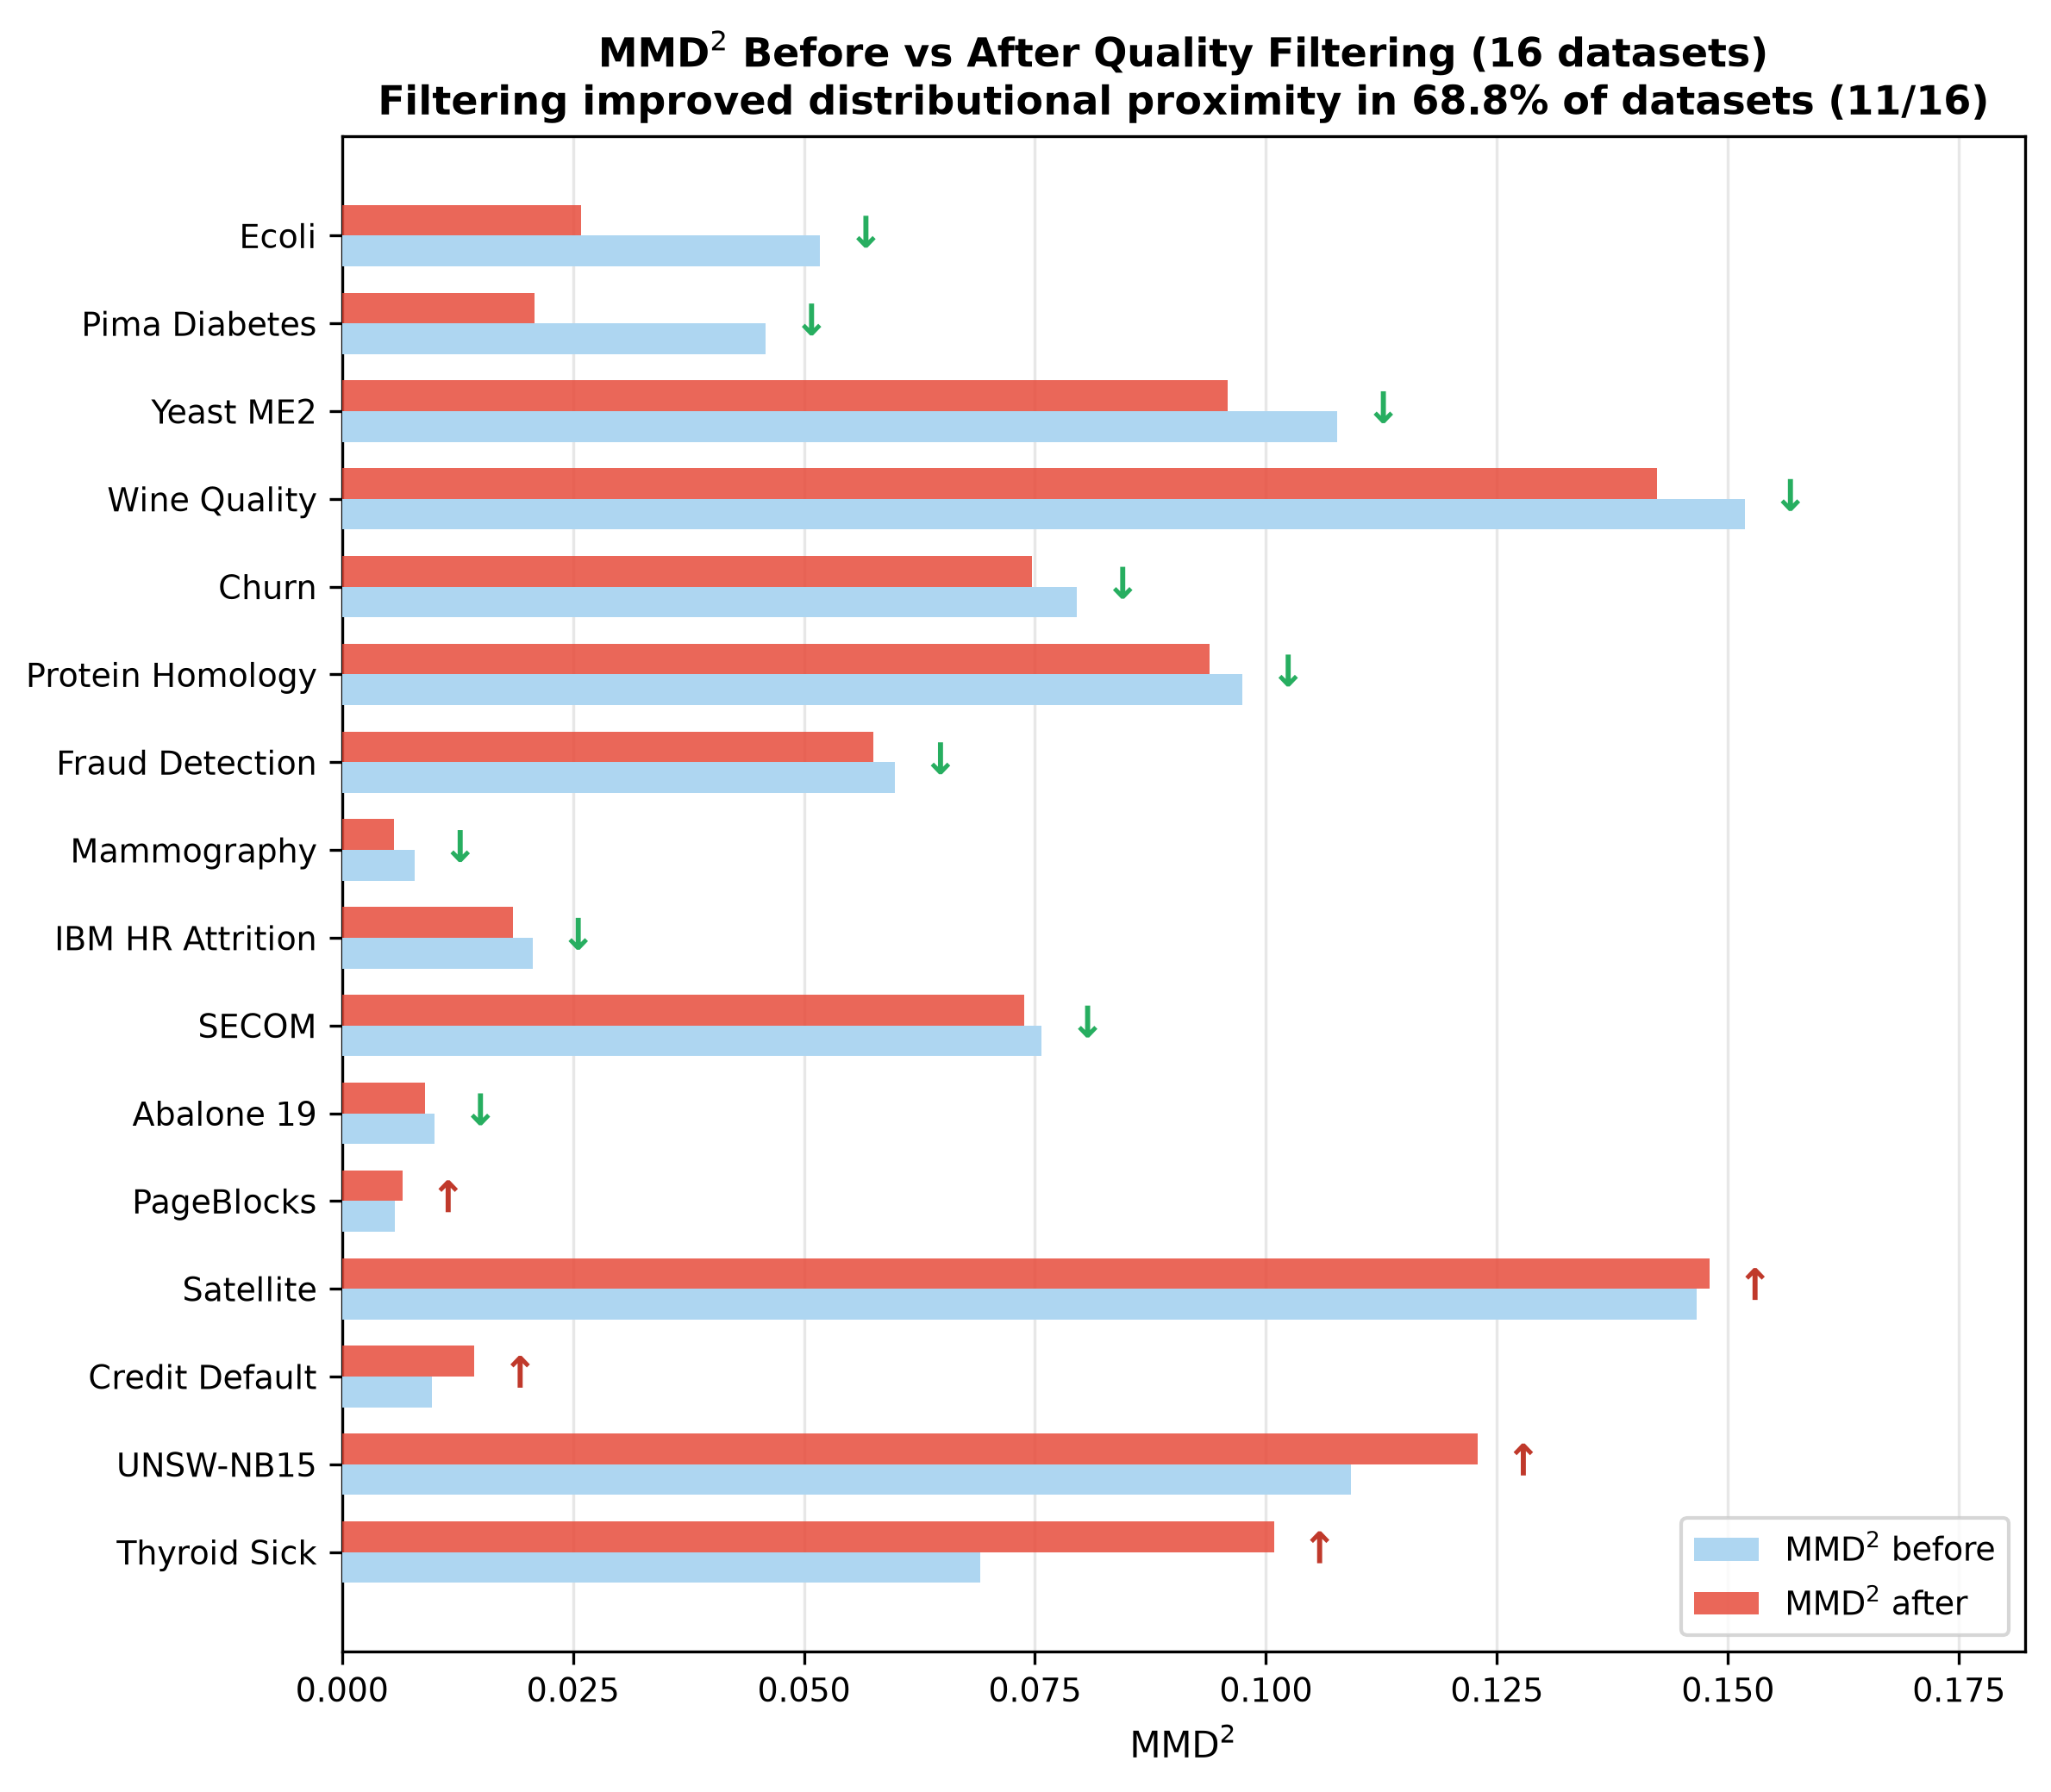

Saved: ./results/fig11_mmd_summary.png / .pdf


In [9]:
"""
Regenerate Figure 6 (fig11_mmd_summary in the manuscript): MMD^2 before
vs after quality filtering, all 16 datasets, proposed configuration
only (adaptive alpha, MMD stage ON), matching the updated Section 4.5
text and Table 8.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

RESULTS_DIR = "./results"

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})

DATASET_ORDER = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "churn", "ecoli", "satellite", "secom", "thyroid_sick", "wine_quality",
    "yeast_me2", "mammography", "abalone_19", "pageblocks",
    "protein_homo", "unsw_nb15",
]
DATASET_LABELS = {
    "credit_default": "Credit Default", "fraud_detection": "Fraud Detection",
    "pima_diabetes": "Pima Diabetes", "ibm_attrition": "IBM HR Attrition",
    "churn": "Churn", "ecoli": "Ecoli", "satellite": "Satellite",
    "secom": "SECOM", "thyroid_sick": "Thyroid Sick", "wine_quality": "Wine Quality",
    "yeast_me2": "Yeast ME2", "mammography": "Mammography", "abalone_19": "Abalone 19",
    "pageblocks": "PageBlocks", "protein_homo": "Protein Homology", "unsw_nb15": "UNSW-NB15",
}

# Load the main results and filter to the proposed configuration only
df_03 = pd.read_csv(f"{RESULTS_DIR}/03_qgctgan_results.csv", keep_default_na=False)
main_config = df_03[
    (df_03["oversampling"] == "Q-G-CTGAN_adaptive_MMDon") &
    (df_03["classifier"] == "RF")
].copy()
main_config["mmd_before"] = pd.to_numeric(main_config["mmd_before"], errors="coerce")
main_config["mmd_after"] = pd.to_numeric(main_config["mmd_after"], errors="coerce")

mmd_df = main_config.set_index("dataset")[["mmd_before", "mmd_after"]].reindex(DATASET_ORDER)
mmd_df["mmd_reduction"] = mmd_df["mmd_before"] - mmd_df["mmd_after"]
mmd_df["improved"] = mmd_df["mmd_reduction"] > 0
mmd_df["label"] = [DATASET_LABELS[d] for d in mmd_df.index]

# Sort by magnitude of improvement (largest reduction at top), matching
# the manuscript table order
mmd_df = mmd_df.sort_values("mmd_reduction", ascending=False)

# ---- Horizontal bar chart ----
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(mmd_df))
h = 0.35

ax.barh(y + h/2, mmd_df["mmd_before"], height=h,
        color="#AED6F1", label="MMD$^2$ before", zorder=3)
ax.barh(y - h/2, mmd_df["mmd_after"], height=h,
        color="#E74C3C", alpha=0.85, label="MMD$^2$ after", zorder=3)

for i, (idx, row) in enumerate(mmd_df.iterrows()):
    sym = "\u2193" if row["improved"] else "\u2191"
    color = "#27AE60" if row["improved"] else "#C0392B"
    xmax = max(row["mmd_before"], row["mmd_after"])
    ax.text(xmax + 0.003, i, sym, ha="left", va="center",
            fontsize=12, color=color, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(mmd_df["label"], fontsize=9)
ax.set_xlabel("MMD$^2$", fontsize=10)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.3, zorder=0)
ax.set_xlim(0, mmd_df[["mmd_before", "mmd_after"]].max().max() * 1.2)
ax.invert_yaxis()

improved_pct = mmd_df["improved"].mean() * 100
ax.set_title(
    f"MMD$^2$ Before vs After Quality Filtering (16 datasets)\n"
    f"Filtering improved distributional proximity in {improved_pct:.1f}% of datasets "
    f"({mmd_df['improved'].sum()}/{len(mmd_df)})",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig11_mmd_summary.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{RESULTS_DIR}/fig11_mmd_summary.pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/fig11_mmd_summary.png / .pdf")

In [11]:
def compute_required_multiplier(n_min, n_maj, target_ratio=TARGET_RATIO,
                                 base_multiplier=CANDIDATE_MULTIPLIER,
                                 safety_factor=MULTIPLIER_SAFETY_FACTOR,
                                 max_multiplier=MAX_MULTIPLIER):
    """
    Returns (multiplier_to_use, n_syn_needed, achievable_ratio_at_cap).
    multiplier_to_use is clipped to [base_multiplier, max_multiplier].
    achievable_ratio_at_cap is the minority ratio actually reachable if
    the multiplier is capped (used only for logging/diagnostics; the
    real achieved ratio after filtering may be lower still).
    """
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)
    if n_min == 0:
        return base_multiplier, n_syn_needed, target_ratio

    required = (n_syn_needed * safety_factor) / n_min
    multiplier_to_use = float(np.clip(required, base_multiplier, max_multiplier))

    max_possible_synthetic = multiplier_to_use * n_min
    achievable_ratio = (n_min + max_possible_synthetic) / (n_maj + n_min + max_possible_synthetic)

    return multiplier_to_use, n_syn_needed, round(achievable_ratio, 4)

print("compute_required_multiplier updated to 3-value return signature.")

compute_required_multiplier updated to 3-value return signature.


In [12]:
print(MULTIPLIER_SAFETY_FACTOR)

1.5


In [14]:
def filter_by_quality(candidates, X_min, labels, X_maj, gmm, best_k,
                      alpha_vec, target_ratio=TARGET_RATIO,
                      mmd_stage_enabled=True):
    """
    Stage 1 — Remove bottom alpha_c quantile fraction by Q(x̃) score
               (intra-cluster outlier removal; alpha_c is a REJECTION
               QUANTILE, see R4-3)
    Stage 2 — Select top n_needed samples by MMD contribution score
               (prioritise samples closest to real minority distribution).
               Skipped when mmd_stage_enabled=False (R1-8 ablation):
               falls back to arbitrary truncation of the Stage-1 pool.
    """
    n_maj = len(X_maj)
    n_min = len(X_min)
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)

    mu_minority_all      = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    filtered_per_cluster = {}
    quality_info         = {}
    stage1_time_start    = time.time()

    for c in range(best_k):
        X_cand = candidates[c]
        X_c    = X_min[labels == c]

        if len(X_cand) == 0 or len(X_c) < 2:
            filtered_per_cluster[c] = np.empty((0, X_min.shape[1]))
            quality_info[c] = {"n_candidate": 0, "n_after_filter": 0,
                               "alpha": alpha_vec[c], "mean_Q_before": np.nan,
                               "mean_Q_after": np.nan}
            continue

        Q = quality_score(
            X_cand, gmm.means_[c], gmm.covariances_[c],
            mu_minority_all, mu_majority_clusters, X_c,
        )
        alpha_c   = alpha_vec[c]
        threshold = np.quantile(Q, alpha_c)
        mask      = Q >= threshold
        X_filt    = X_cand[mask]

        quality_info[c] = {
            "n_candidate"   : len(X_cand),
            "n_after_filter": int(mask.sum()),
            "alpha"         : round(float(alpha_c), 3),
            "mean_Q_before" : round(float(Q.mean()), 4),
            "mean_Q_after"  : round(float(Q[mask].mean()), 4) if mask.sum() > 0 else np.nan,
        }
        filtered_per_cluster[c] = X_filt

    stage1_time = round(time.time() - stage1_time_start, 3)

    stage2_time_start = time.time()
    all_filtered = [v for v in filtered_per_cluster.values() if len(v) > 0]
    if not all_filtered:
        return (np.empty((0, X_min.shape[1])), quality_info,
                {"stage1_time": stage1_time, "stage2_time": 0.0})

    X_pool = np.vstack(all_filtered)

    if not mmd_stage_enabled:
        X_final = X_pool[:n_syn_needed] if len(X_pool) > n_syn_needed else X_pool
        stage2_time = round(time.time() - stage2_time_start, 3)
        return X_final, quality_info, {"stage1_time": stage1_time, "stage2_time": stage2_time}

    if len(X_pool) <= n_syn_needed:
        stage2_time = round(time.time() - stage2_time_start, 3)
        return X_pool, quality_info, {"stage1_time": stage1_time, "stage2_time": stage2_time}

    gamma = median_bandwidth(X_min, X_pool)
    mmd_scores = np.array([
        mmd_contribution(X_pool[i], X_min, X_pool, gamma)
        for i in range(len(X_pool))
    ])
    top_idx = np.argsort(mmd_scores)[:n_syn_needed]
    stage2_time = round(time.time() - stage2_time_start, 3)
    return X_pool[top_idx], quality_info, {"stage1_time": stage1_time, "stage2_time": stage2_time}

print("filter_by_quality updated to 3-value return signature.")

filter_by_quality updated to 3-value return signature.


  GMM: best_k=4  cluster_sizes=[62, 40, 59, 26]  [0.3s]
  Target synthetic samples (Delta, 50% balance): 163
  Candidate multiplier: 5.0x [within cap]
  Training 4 CTGAN models...
  Generating candidates (x5.0)...
  Total candidates generated: 935  [0.6s]  (target=163, sufficient)
  Adaptive alpha: [0.1   0.3   0.296 0.284]
  Filtering by quality score Q(x̃)... (MMD stage: ON)
  Filtered: 935 -> 163 samples [0.1s]
  MMD^2 before=0.067490  after=0.015272  (improved)


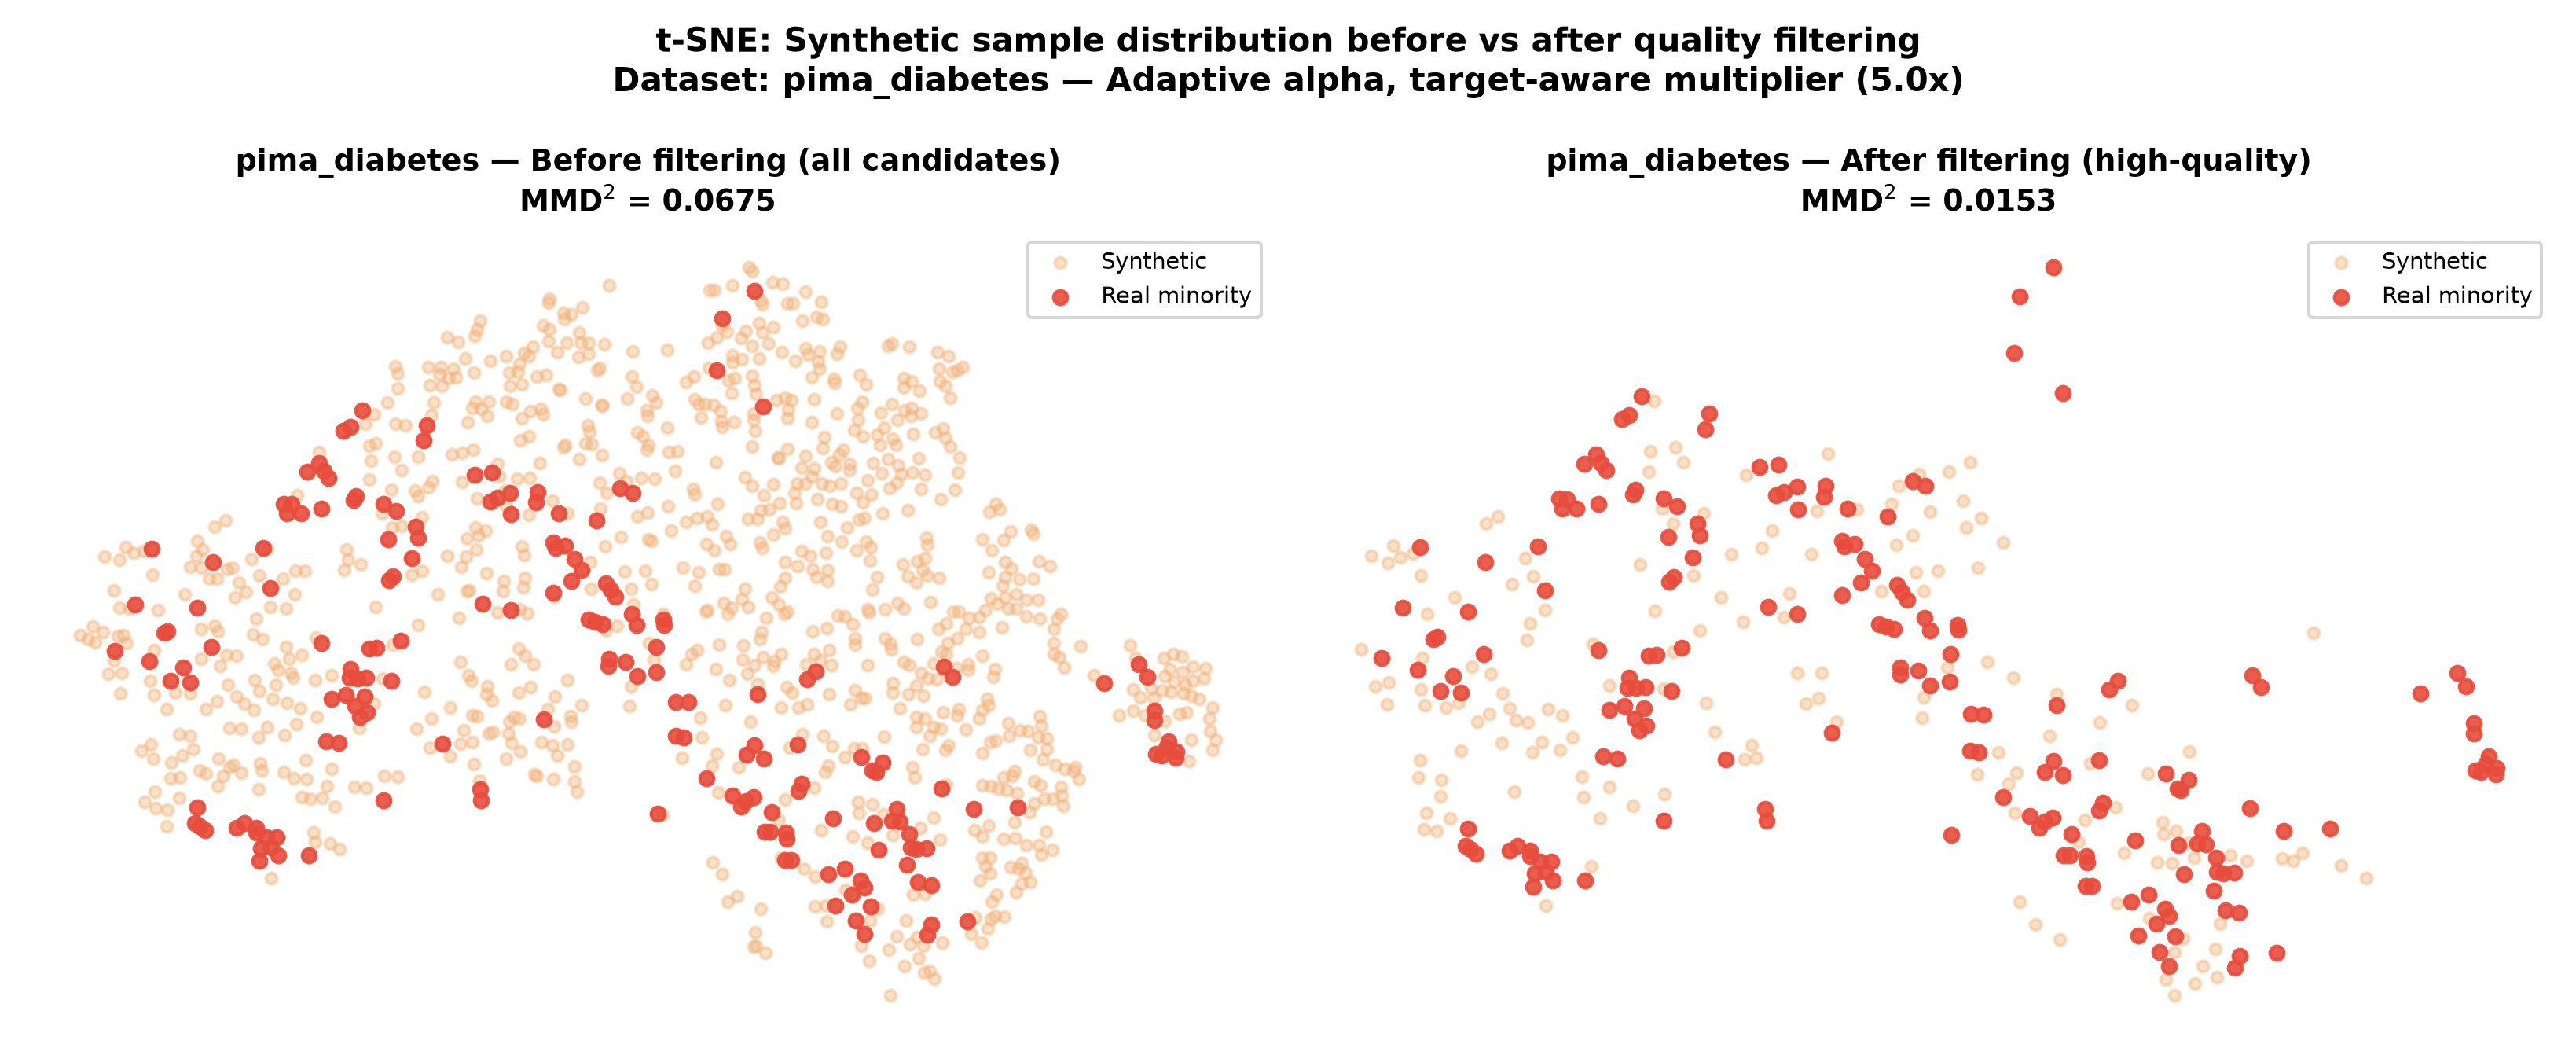

Saved: fig05_tsne_pima_diabetes.png / .pdf
  GMM: best_k=3  cluster_sizes=[32, 1, 3]  [0.1s]
  Target synthetic samples (Delta, 50% balance): 966
  Candidate multiplier: 40.2x [within cap]
  Training 3 CTGAN models...
  Generating candidates (x40.2)...
  Total candidates generated: 1,409  [0.6s]  (target=966, sufficient)
  Adaptive alpha: [0.3 0.3 0.1]
  Filtering by quality score Q(x̃)... (MMD stage: ON)
  Filtered: 1,409 -> 966 samples [0.1s]
  MMD^2 before=0.087967  after=0.074432  (improved)


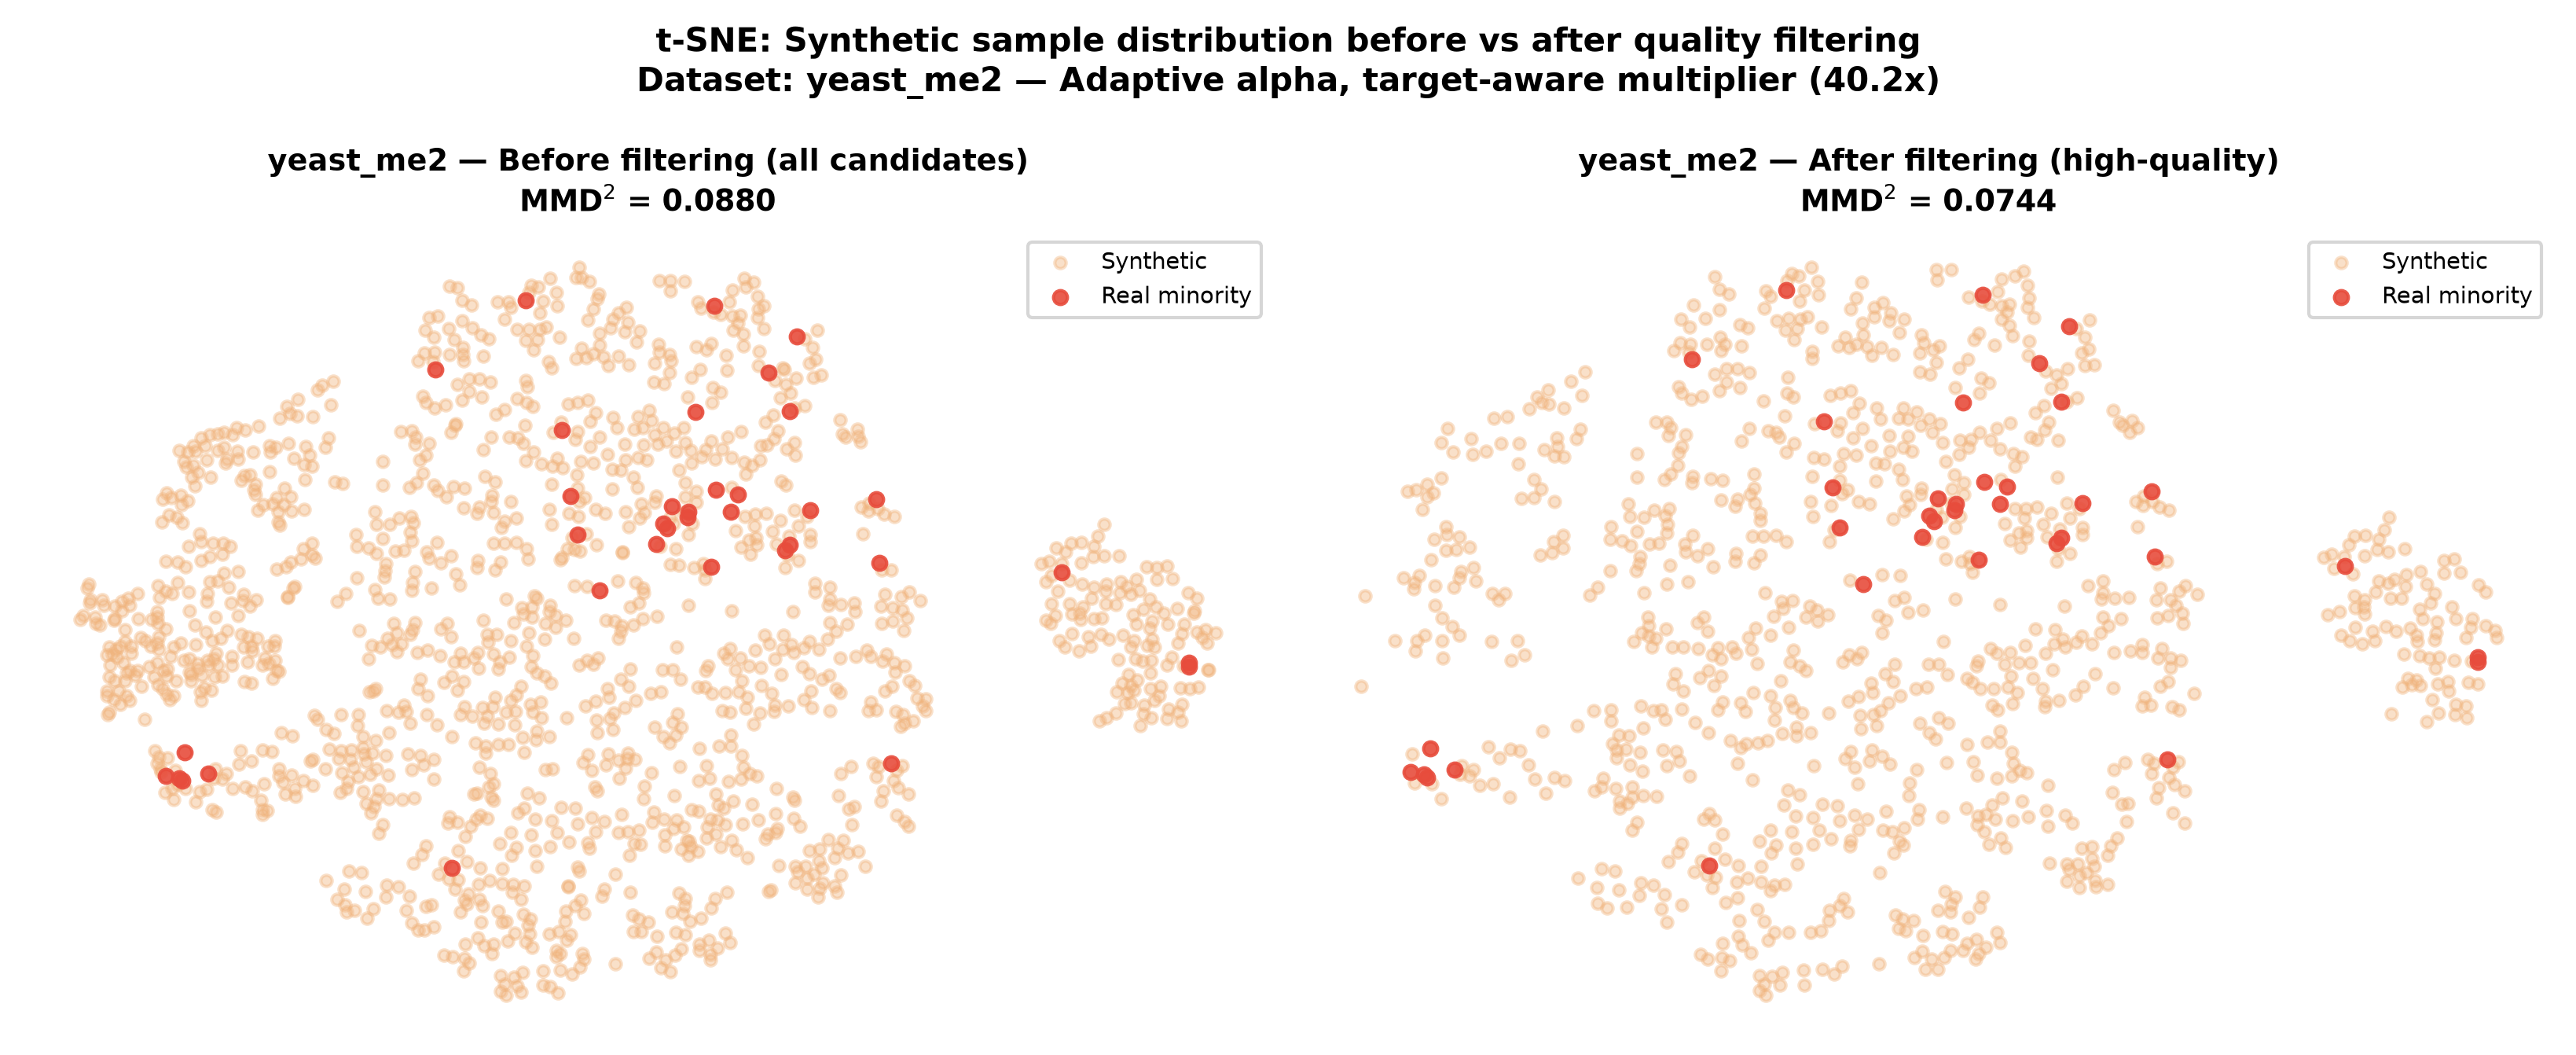

Saved: fig05_tsne_yeast_me2.png / .pdf


In [15]:
"""
Regenerate Figure 5 (t-SNE before/after quality filtering) using the
current pipeline (target-aware candidate multiplier, quantile-based
Stage-1 filtering), for the same two representative datasets as an
earlier version of this figure (Pima Diabetes, Yeast ME2), to ensure
reproducibility with the corrected pipeline (Section 3.4).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})

RANDOM_STATE = 42
DATASET_DIR = "./datasets"
RESULTS_DIR = "./results"


def plot_tsne_filter_v2(ds_name, random_state=RANDOM_STATE):
    """
    Uses the current target-aware pipeline: qgctgan_prepare() for GMM +
    CTGAN + candidate generation, then a single quantile-based Stage-1
    filter pass (adaptive alpha, matching the main results
    configuration) to obtain the filtered set for visualization.
    """
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    df = pd.read_csv(path)
    bool_cols = df.select_dtypes(include="bool").columns
    if len(bool_cols):
        df[bool_cols] = df[bool_cols].astype("float64")

    X = df.drop(columns=["target"]).values.astype(float)
    y = df["target"].values.astype(int)
    X_tr, _, y_tr, _ = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )
    X_tr = StandardScaler().fit_transform(X_tr)

    # Use the current pipeline (qgctgan_prepare/qgctgan_filter from
    # Notebook 03), which already incorporates the target-aware
    # multiplier (Eq. multiplier) and quantile-based Stage-1 filter
    # (Eq. stage1filter).
    y_tr_arr = y_tr
    prepared = qgctgan_prepare(X_tr.copy(), y_tr_arr.copy(), random_state=random_state)
    X_syn_filt, y_syn_res, info = qgctgan_filter(
        prepared, alpha_mode="adaptive", mmd_stage_enabled=True
    )

    X_min = prepared["X_min"]
    candidates = prepared["candidates"]
    X_cand_all = np.vstack([v for v in candidates.values() if len(v) > 0])

    # X_syn_filt from qgctgan_filter is the full reconstructed dataset
    # (majority + minority + synthetic); extract only the newly added
    # synthetic minority rows for the "after filtering" panel.
    n_maj = len(prepared["X_maj"])
    n_min = len(X_min)
    X_syn_only = X_syn_filt[n_maj + n_min:]

    if len(X_cand_all) == 0 or len(X_syn_only) == 0:
        print(f"  Skipping t-SNE for {ds_name}: no synthetic samples.")
        return

    N_real = len(X_min)
    N_cand = len(X_cand_all)
    X_all = np.vstack([X_min, X_cand_all, X_syn_only])
    Z = TSNE(n_components=2, random_state=random_state,
             perplexity=min(30, len(X_all) - 1)).fit_transform(X_all)

    Z_real = Z[:N_real]
    Z_cand = Z[N_real:N_real + N_cand]
    Z_filt = Z[N_real + N_cand:]

    mmd_b = info["mmd_before"]
    mmd_a = info["mmd_after"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, (Z_syn, title, mmd_val) in zip(axes, [
        (Z_cand, "Before filtering (all candidates)", mmd_b),
        (Z_filt, "After filtering (high-quality)", mmd_a),
    ]):
        ax.scatter(Z_syn[:, 0], Z_syn[:, 1],
                   c="#F0B27A", alpha=0.4, s=12, label="Synthetic")
        ax.scatter(Z_real[:, 0], Z_real[:, 1],
                   c="#E74C3C", alpha=0.9, s=18, label="Real minority")
        mmd_str = f"{mmd_val:.4f}" if mmd_val is not None else "N/A"
        ax.set_title(f"{ds_name} — {title}\nMMD$^2$ = {mmd_str}",
                     fontsize=9, fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    plt.suptitle(
        f"t-SNE: Synthetic sample distribution before vs after quality filtering\n"
        f"Dataset: {ds_name} — Adaptive alpha, target-aware multiplier ({info['candidate_multiplier_used']:.1f}x)",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, f"fig05_tsne_{ds_name}.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(RESULTS_DIR, f"fig05_tsne_{ds_name}.pdf"), bbox_inches="tight")
    plt.show()
    print(f"Saved: fig05_tsne_{ds_name}.png / .pdf")


for ds in ["pima_diabetes", "yeast_me2"]:
    plot_tsne_filter_v2(ds)